# Vaideeka Agrawal 12241960

**Dataset Link:** https://www.kaggle.com/datasets/princelv84/dogsvscats

**Instructions**
1. This dataset contains 10,000 cat images and 10,000 dog images in 'train' folder.
2. Please use only 2000 images from each class to train the model.
3. You can train the model upto 15 Epochs.

In [ ]:
!pip install torch torchvision matplotlib --quiet

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("princelv84/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [ ]:
import zipfile
import os

zip_path = '/content/catvsdog.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Extracted files:", os.listdir('dataset'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/catvsdog.zip'

In [ ]:
import shutil
import random

base_dir = 'dataset'
train_dir = 'data_split/train'
val_dir = 'data_split/val'

classes = ['cat', 'dog']

for cls in classes:
    os.makedirs(f"{train_dir}/{cls}", exist_ok=True)
    os.makedirs(f"{val_dir}/{cls}", exist_ok=True)

    images = os.listdir(f"{base_dir}/{cls}")
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    val_imgs = images[split:]

    for img in train_imgs:
        shutil.copy(f"{base_dir}/{cls}/{img}", f"{train_dir}/{cls}/{img}")

    for img in val_imgs:
        shutil.copy(f"{base_dir}/{cls}/{img}", f"{val_dir}/{cls}/{img}")

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['cat', 'dog']


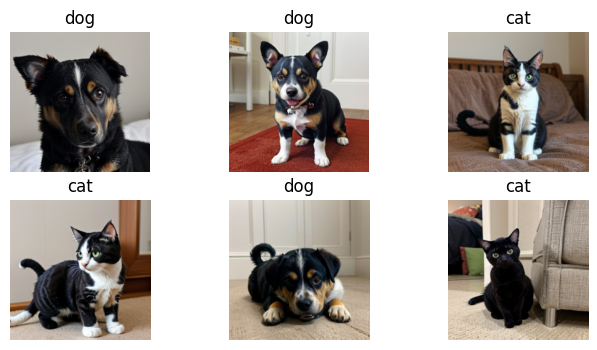

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(8,4))
for i in range(6):
    img = images[i].permute(1,2,0)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis('off')

plt.show()

In [ ]:
model = torchvision.models.alexnet(pretrained=True)

# Modify classifier for 2 classes
model.classifier[6] = nn.Linear(4096, 2)
model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 196MB/s]


# Fine-Tuning (Transfer Learning)

## What is happening here?

We are using a pre-trained CNN model (AlexNet) that was originally trained on a large dataset (ImageNet), and adapting it to our task (Cat vs Dog classification).

This process is called **Transfer Learning**.

---

## Types of Transfer Learning

### 1. Feature Extraction
- Freeze convolutional layers
- Train only the final classifier layer
- Faster and requires less data

---

### 2. Fine-Tuning (What we are doing)

- Use pre-trained weights
- Replace the final classification layer
- Train the entire network on new data

---

## In this notebook

We are performing:

**Full Fine-Tuning of AlexNet**

- Pretrained weights are used as initialization  
- Entire model is updated during training  
- Final layer is modified for 2 classes (Cat vs Dog)  

---

## Why use Fine-Tuning?

- Faster convergence compared to training from scratch  
- Requires less data  
- Leverages learned features like edges, textures, shapes  

---

## Important Notes

- Fine-tuning works best when new dataset is similar to original dataset  
- Too much training may lead to overfitting  
- Learning rate should be small  

---


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0472
Epoch 2, Loss: 0.0212
Epoch 3, Loss: 0.0006



## Visualizing Filters/Kernels

###  Description
Convolutional layers learn filters (kernels) that detect patterns such as:
- Edges  
- Colors  
- Textures  

### What to observe
- Early layers detect simple patterns  
- Filters resemble edge detectors or color blobs  

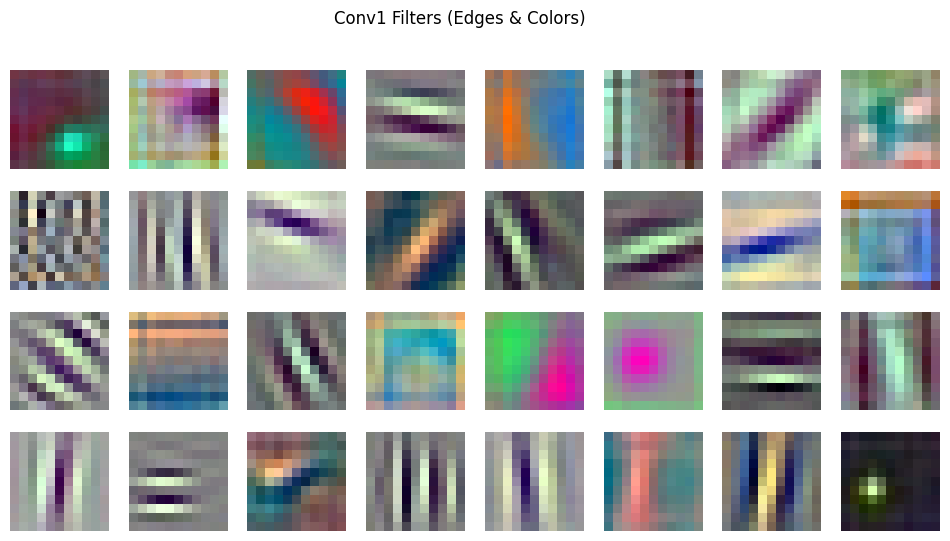

In [ ]:
def visualize_filters(layer, title="Filters"):
    weights = layer.weight.data.clone().cpu()

    num_filters = weights.shape[0]

    fig, axes = plt.subplots(4, 8, figsize=(12,6))
    axes = axes.flatten()

    for i in range(32):  # show first 32 filters
        filt = weights[i]

        # Normalize for visualization
        filt = (filt - filt.min()) / (filt.max() - filt.min())

        filt = filt.permute(1,2,0)  # C,H,W → H,W,C

        axes[i].imshow(filt)
        axes[i].axis('off')

    plt.suptitle(title)
    plt.show()


# First conv layer
visualize_filters(model.features[0], "Conv1 Filters (Edges & Colors)")

**Visualise Filters in Deep Layers**


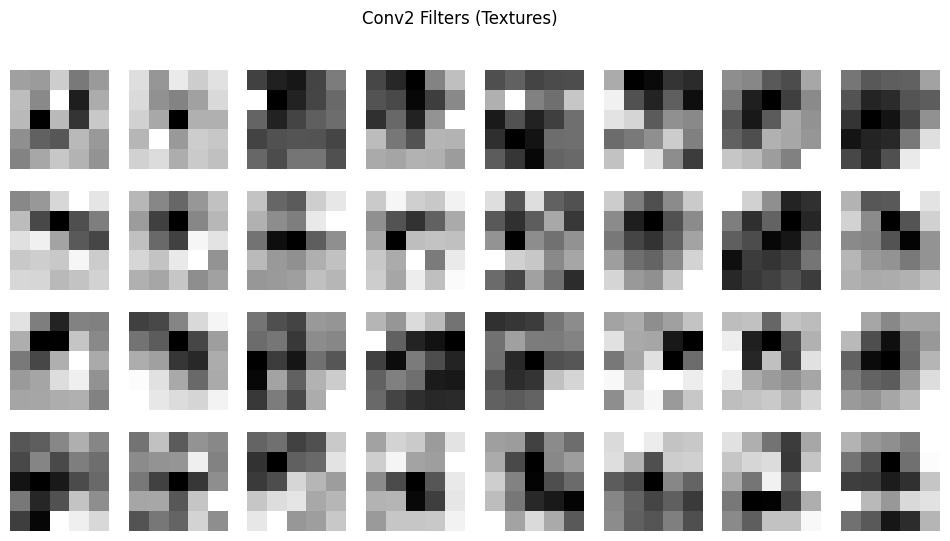

In [ ]:
def visualize_deep_filters(layer, title="Deep Filters"):
    weights = layer.weight.data.clone().cpu()

    fig, axes = plt.subplots(4, 8, figsize=(12,6))
    axes = axes.flatten()

    for i in range(32):
        filt = weights[i, 0]  # take 1 channel

        filt = (filt - filt.min()) / (filt.max() - filt.min())

        axes[i].imshow(filt, cmap='gray')
        axes[i].axis('off')

    plt.suptitle(title)
    plt.show()


# Example deeper layer
visualize_deep_filters(model.features[3], "Conv2 Filters (Textures)")

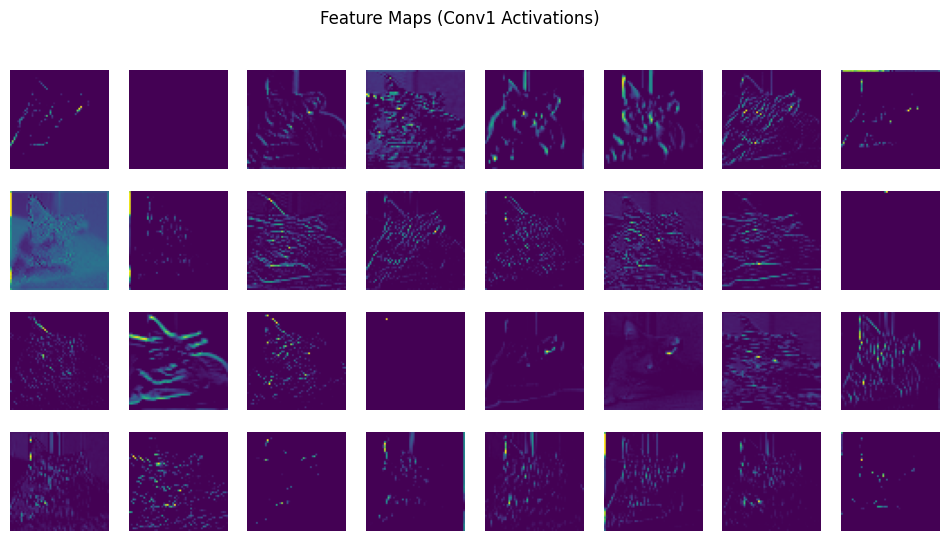

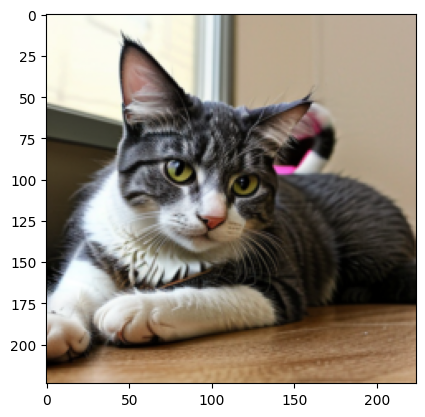

In [ ]:
def visualize_feature_maps(model, image):
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    # Hook first conv layer
    hook = model.features[0].register_forward_hook(hook_fn)

    _ = model(image)

    act = activations[0].detach().cpu()

    fig, axes = plt.subplots(4, 8, figsize=(12,6))
    axes = axes.flatten()

    for i in range(32):
        fmap = act[0, i]
        axes[i].imshow(fmap, cmap='viridis')
        axes[i].axis('off')

    plt.suptitle("Feature Maps (Conv1 Activations)")
    plt.show()

    hook.remove()


# Get one image from the val_loader in the correct format (1, C, H, W)
# and move it to the device
images_batch, _ = next(iter(val_loader))
img_for_model = images_batch[1].unsqueeze(0).to(DEVICE)

visualize_feature_maps(model, img_for_model)
plt.imshow(img_for_model.squeeze().cpu().numpy().transpose(1,2,0))

## Maximally Activating Image Patches

### Description
Each filter responds strongly to certain regions of the image.
We extract image patches that produce maximum activation.

### What to observe
- Which parts of the image activate specific filters  
- Deeper layers capture meaningful structures (e.g., fur, face)  

What are we doing?
- We pass an image through the model
- Find where a filter activates the most
- Extract that part of the image


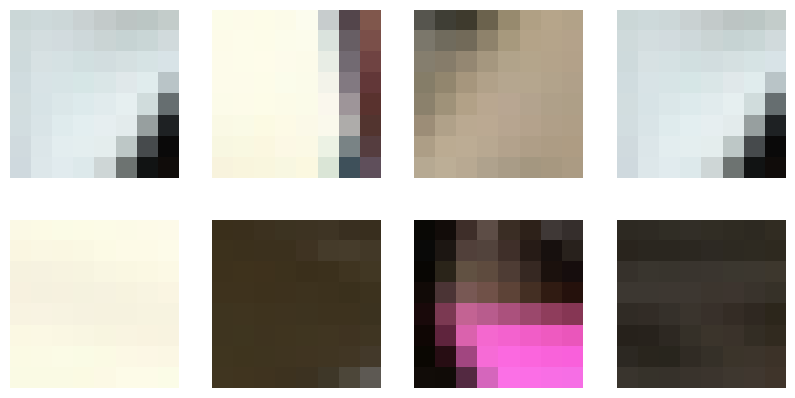

In [ ]:
def get_activations(model, image, layer):
    acts = []
    def hook(m,i,o): acts.append(o.detach())
    h = layer.register_forward_hook(hook)
    _ = model(image)
    h.remove()
    return acts[0]

def show_patches(image, activations):
    image = image.squeeze().cpu().numpy().transpose(1,2,0)
    act = activations.squeeze().cpu().numpy()

    plt.figure(figsize=(10,5))

    for i in range(8):
        fmap = act[i]
        y,x = np.unravel_index(np.argmax(fmap), fmap.shape)

        h_ratio = image.shape[0]//fmap.shape[0]
        w_ratio = image.shape[1]//fmap.shape[1]

        patch = image[y*h_ratio:(y+1)*h_ratio, x*w_ratio:(x+1)*w_ratio]

        plt.subplot(2,4,i+1)
        plt.imshow(patch)
        plt.axis('off')

    plt.show()

acts = get_activations(model, img_for_model, model.features[3])
show_patches(img_for_model, acts)

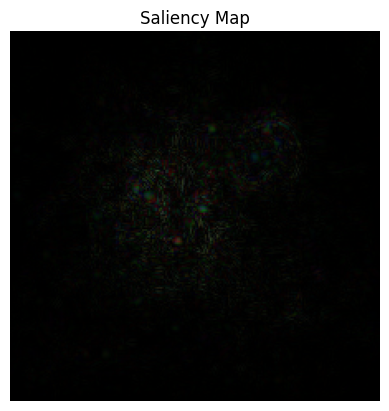

In [ ]:
img_for_model.requires_grad = True
output = model(img_for_model)

score = output[0, torch.argmax(output)]
model.zero_grad()
score.backward()

saliency = img_for_model.grad.data.abs().squeeze().cpu().numpy().transpose(1,2,0)

plt.imshow(saliency)
plt.title("Saliency Map")
plt.axis('off')
plt.show()


## Task 1: Occlusion Sensitivity

### Description
Parts of the image are masked (occluded) to observe changes in prediction.

### Task
- Slide a patch across the image  
- Replace region with zeros or mean value  
- Measure change in prediction  

### Expected Output
- Heatmap  
- Overlay on original image  

What are we doing?
- We cover (mask) small parts of the image
- Check how prediction changes

In [ ]:
!kaggle datasets download -d princelv84/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/princelv84/dogsvscats
License(s): MIT
100% 545M/545M [00:14<00:00, 40.1MB/s]



In [ ]:
!unzip dogsvscats.zip -d data/

Streaming output truncated to the last 5000 lines.
  inflating: data/train/dogs/dog.4419.jpg  
  inflating: data/train/dogs/dog.442.jpg  
  inflating: data/train/dogs/dog.4420.jpg  
  inflating: data/train/dogs/dog.4421.jpg  
  inflating: data/train/dogs/dog.4422.jpg  
  inflating: data/train/dogs/dog.4424.jpg  
  inflating: data/train/dogs/dog.4425.jpg  
  inflating: data/train/dogs/dog.4426.jpg  
  inflating: data/train/dogs/dog.4427.jpg  
  inflating: data/train/dogs/dog.4431.jpg  
  inflating: data/train/dogs/dog.4433.jpg  
  inflating: data/train/dogs/dog.4436.jpg  
  inflating: data/train/dogs/dog.4438.jpg  
  inflating: data/train/dogs/dog.4439.jpg  
  inflating: data/train/dogs/dog.444.jpg  
  inflating: data/train/dogs/dog.4440.jpg  
  inflating: data/train/dogs/dog.4441.jpg  
  inflating: data/train/dogs/dog.4442.jpg  
  inflating: data/train/dogs/dog.4443.jpg  
  inflating: data/train/dogs/dog.4444.jpg  
  inflating: data/train/dogs/dog.4445.jpg  
  inflating: data/train/dog

In [ ]:
import os

print(os.listdir("data"))

['subset', 'train', 'test']


In [ ]:
print(os.listdir("data/train"))

['dogs', 'cats']


In [ ]:
import os
import shutil
import random

# -----------------------------
# CONFIG
# -----------------------------
CATS_SOURCE = "data/train/cats"
DOGS_SOURCE = "data/train/dogs"

TARGET_DIR = "data/subset"
CATS_TARGET = os.path.join(TARGET_DIR, "cats")
DOGS_TARGET = os.path.join(TARGET_DIR, "dogs")

NUM_IMAGES = 2000
random.seed(42)

# -----------------------------
# CREATE TARGET FOLDERS
# -----------------------------
os.makedirs(CATS_TARGET, exist_ok=True)
os.makedirs(DOGS_TARGET, exist_ok=True)

# -----------------------------
# LOAD FILES
# -----------------------------
cats = os.listdir(CATS_SOURCE)
dogs = os.listdir(DOGS_SOURCE)

print(f"Total cats found: {len(cats)}")
print(f"Total dogs found: {len(dogs)}")

# -----------------------------
# SAFETY CHECK
# -----------------------------
if len(cats) < NUM_IMAGES or len(dogs) < NUM_IMAGES:
    raise ValueError("❌ Not enough images!")

# -----------------------------
# SAMPLE 2000
# -----------------------------
cats_sample = random.sample(cats, NUM_IMAGES)
dogs_sample = random.sample(dogs, NUM_IMAGES)

# -----------------------------
# COPY FILES
# -----------------------------
print("Copying cats...")
for i, f in enumerate(cats_sample):
    shutil.copy(os.path.join(CATS_SOURCE, f),
                os.path.join(CATS_TARGET, f))
    if (i+1) % 500 == 0:
        print(f"{i+1} cats copied")

print("Copying dogs...")
for i, f in enumerate(dogs_sample):
    shutil.copy(os.path.join(DOGS_SOURCE, f),
                os.path.join(DOGS_TARGET, f))
    if (i+1) % 500 == 0:
        print(f"{i+1} dogs copied")

print("✅ DONE! Subset created at:", TARGET_DIR)

Total cats found: 10000
Total dogs found: 10000
Copying cats...
500 cats copied
1000 cats copied
1500 cats copied
2000 cats copied
Copying dogs...
500 dogs copied
1000 dogs copied
1500 dogs copied
2000 dogs copied
✅ DONE! Subset created at: data/subset


Train–Validation Split

In [ ]:
import os, shutil, random

base_dir = "data/subset"
train_dir = "data_split/train"
val_dir = "data_split/val"

classes = ["cats", "dogs"]

for cls in classes:
    os.makedirs(f"{train_dir}/{cls}", exist_ok=True)
    os.makedirs(f"{val_dir}/{cls}", exist_ok=True)

    images = os.listdir(f"{base_dir}/{cls}")
    random.shuffle(images)

    split = int(0.8 * len(images))  # 80-20 split

    train_imgs = images[:split]
    val_imgs = images[split:]

    for img in train_imgs:
        shutil.copy(f"{base_dir}/{cls}/{img}", f"{train_dir}/{cls}/{img}")

    for img in val_imgs:
        shutil.copy(f"{base_dir}/{cls}/{img}", f"{val_dir}/{cls}/{img}")

print("✅ Train/Val split done")

✅ Train/Val split done


Data Loaders

In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['cats', 'dogs']


Normalize Images

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Model Setup

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.alexnet(pretrained=True)

# Freeze feature extractor (recommended for small dataset)
for param in model.features.parameters():
    param.requires_grad = False

# Modify classifier
model.classifier[6] = nn.Linear(4096, 2)

model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 127MB/s]


Loss + Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

# Only train classifier (faster + better)
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

 Training Loop

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

Epoch 1: Loss=0.3053, Train Acc=86.91%, Val Acc=92.00%
Epoch 2: Loss=0.1720, Train Acc=93.47%, Val Acc=91.75%
Epoch 3: Loss=0.1268, Train Acc=94.66%, Val Acc=91.62%
Epoch 4: Loss=0.1016, Train Acc=95.97%, Val Acc=92.62%
Epoch 5: Loss=0.0783, Train Acc=97.06%, Val Acc=92.25%


In [ ]:
images_batch, _ = next(iter(val_loader))
img_for_model = images_batch[0].unsqueeze(0).to(DEVICE)

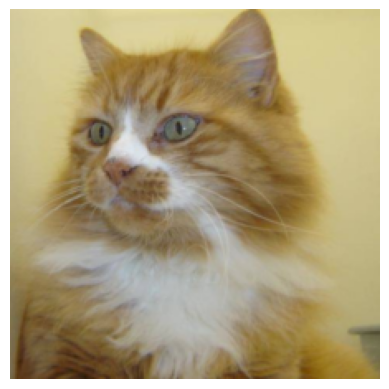

In [ ]:
img = img_for_model.squeeze().cpu().numpy().transpose(1,2,0)

plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
print(img_for_model.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
img = img_for_model.squeeze().cpu().numpy()
print(img.min(), img.max())

0.003921569 0.93333334


**Task 1 Solution**

In [ ]:
def occlusion_sensitivity(model, image, patch_size=30, stride=15):
    model.eval()

    image = image.clone().to(DEVICE)
    _, _, H, W = image.shape

    # Original prediction
    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs)
        base_prob = probs[0, pred_class].item()

    heatmap = np.zeros((H, W))

    # Use mean pixel instead of zero (more natural)
    mean_val = image.mean().item()

    for y in range(0, H, stride):
        for x in range(0, W, stride):
            occluded = image.clone()

            occluded[:, :, y:y+patch_size, x:x+patch_size] = mean_val

            with torch.no_grad():
                out = model(occluded)
                prob = torch.softmax(out, dim=1)[0, pred_class].item()

            # ✅ IMPORTANT: measure DROP in confidence
            drop = base_prob - prob

            heatmap[y:y+patch_size, x:x+patch_size] = drop

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)

    return heatmap

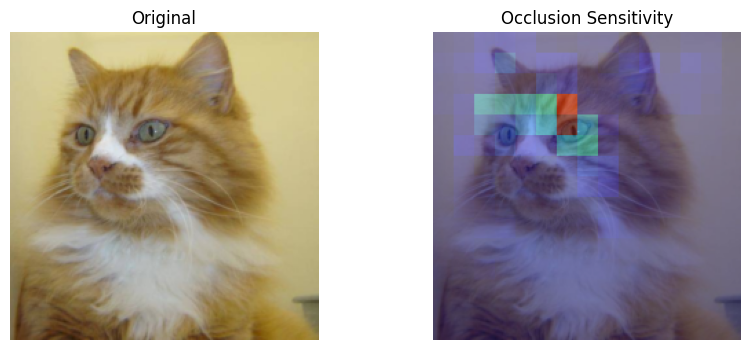

In [ ]:
occ_map = occlusion_sensitivity(model, img_for_model)

# Get original image (NO denormalization if not normalized)
orig = img_for_model.squeeze().cpu().numpy().transpose(1,2,0)

plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis('off')

# Occlusion Overlay (🔥 BEST)
plt.subplot(1,2,2)
plt.imshow(orig)
plt.imshow(occ_map, cmap='jet', alpha=0.4)
plt.title("Occlusion Sensitivity")
plt.axis('off')

plt.show()

## Backpropagation to Image (Saliency Map)

### Description
This method computes the gradient of the output class with respect to the input image.

### What to observe
- Bright regions indicate important pixels  
- Output may be noisy but highlights pixel-level importance  

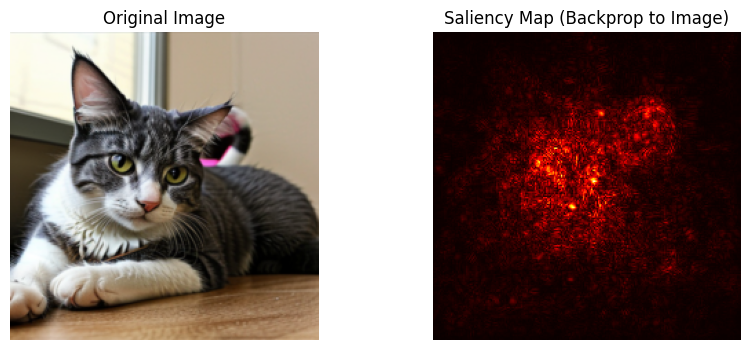

In [ ]:

def saliency_map(model, image):
    model.eval()

    image = image.clone().detach().to(DEVICE)
    image.requires_grad = True

    # Forward pass
    output = model(image)
    pred_class = torch.argmax(output)

    # Backward pass
    model.zero_grad()
    output[0, pred_class].backward()

    # Get gradients
    saliency = image.grad.data.abs()

    # Take max across RGB channels
    saliency, _ = torch.max(saliency, dim=1)

    return saliency.squeeze().cpu().numpy()


# Generate saliency
sal = saliency_map(model, img_for_model)


plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)
orig = img_for_model.squeeze().cpu().detach().numpy().transpose(1,2,0)
orig = (orig - orig.min()) / (orig.max() - orig.min())
plt.imshow(orig)
plt.title("Original Image")
plt.axis('off')

# Saliency Map
plt.subplot(1,2,2)
plt.imshow(sal, cmap='hot')
plt.title("Saliency Map (Backprop to Image)")
plt.axis('off')

plt.show()

## Task 2: Image Reconstruction from Latent Representation

### Description
CNNs encode images into latent feature representations.
You will reconstruct the image from these features.

### Task
- Extract features from the model  
- Design a decoder network  
- Reconstruct the input image  

### Expected Output
- Original image vs reconstructed image  

### Learning Outcome
Understand what information is preserved in deep features.

Encoder

In [ ]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, pretrained_model):
        super().__init__()
        self.features = pretrained_model.features  # AlexNet conv layers

    def forward(self, x):
        x = self.features(x)
        return x

Decoder

In [ ]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.decoder = nn.Sequential(
            # 256x6x6 → 128x12x12
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2),
            nn.ReLU(),

            # 128x12x12 → 64x24x24
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2),
            nn.ReLU(),

            # 64x24x24 → 32x48x48
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2),
            nn.ReLU(),

            # 32x48x48 → 16x96x96
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2),
            nn.ReLU(),

            # 16x96x96 → 3x224x224
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

Initialize Models

In [ ]:
encoder = Encoder(model).to(DEVICE)
decoder = Decoder().to(DEVICE)

# Freeze encoder (VERY IMPORTANT)
for param in encoder.parameters():
    param.requires_grad = False

Loss + Optimizer

In [ ]:
criterion_recon = nn.MSELoss()
optimizer_recon = torch.optim.Adam(decoder.parameters(), lr=1e-3)

Training Loop

In [ ]:
EPOCHS_RECON = 5

for epoch in range(EPOCHS_RECON):
    decoder.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(DEVICE)

        # Extract features (no grad)
        with torch.no_grad():
            features = encoder(images)

        # Reconstruct
        recon = decoder(features)

        loss = criterion_recon(recon, images)

        optimizer_recon.zero_grad()
        loss.backward()
        optimizer_recon.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Reconstruction Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Reconstruction Loss: 0.0534
Epoch 2, Reconstruction Loss: 0.0368
Epoch 3, Reconstruction Loss: 0.0343
Epoch 4, Reconstruction Loss: 0.0327
Epoch 5, Reconstruction Loss: 0.0313


Visualization

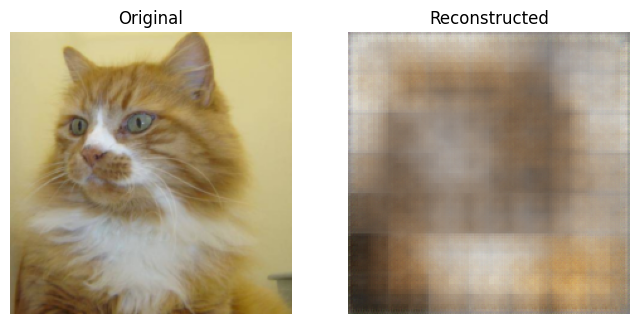

In [ ]:
decoder.eval()

images_batch, _ = next(iter(val_loader))
img = images_batch[0].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    feat = encoder(img)
    recon = decoder(feat)

# Convert to numpy
orig = img.squeeze().cpu().numpy().transpose(1,2,0)
recon_img = recon.squeeze().cpu().numpy().transpose(1,2,0)

# If normalized → denormalize
# orig = denormalize(img).squeeze().cpu().numpy().transpose(1,2,0)

orig = np.clip(orig, 0, 1)
recon_img = np.clip(recon_img, 0, 1)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(recon_img)
plt.title("Reconstructed")
plt.axis('off')

plt.show()

## CAM (Class Activation Mapping)

### Description
CAM highlights regions of the image responsible for classification.

Note:
Since AlexNet does not use Global Average Pooling, this is an approximate implementation.

### What to observe
- Rough localization of the object  
- Less precise than Grad-CAM  

What are we doing?
- Use feature maps to highlight important regions

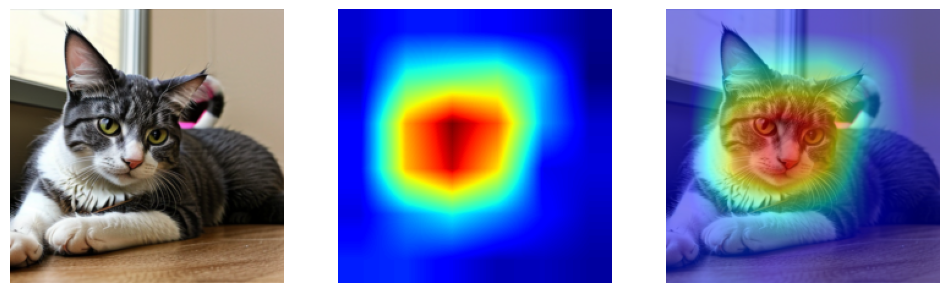

In [ ]:
def overlay(image_tensor, cam_map_array):
    # Convert image tensor to numpy for display
    # image_tensor is (1, C, H, W)
    original_image_np = image_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    original_image_np = (original_image_np - original_image_np.min()) / (original_image_np.max() - original_image_np.min() + 1e-8) # Normalize to 0-1

    # Resize CAM to original image size
    h, w, _ = original_image_np.shape
    cam_resized = cv2.resize(cam_map_array, (w, h))
    cam_normalized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8) # Normalize to 0-1, add epsilon for stability

    # Apply colormap to CAM
    heatmap = plt.cm.jet(cam_normalized)[:,:,:3] # Get RGB from colormap, discard alpha

    # Create overlay
    overlay_image = original_image_np * 0.5 + heatmap * 0.5

    return original_image_np, heatmap, overlay_image

def cam_demo(model, image):
    model.eval()

    # Get features from last conv layer
    feats = []
    def hook_fn(m, i, o): feats.append(o.detach())
    h = model.features[-1].register_forward_hook(hook_fn)

    out = model(image)
    cls = torch.argmax(out)
    h.remove()

    feature_maps = feats[0]  # [1, C, H, W]

    # Use classifier weights corresponding to predicted class
    # Note: AlexNet's classifier is fully connected, direct mapping to conv features isn't straightforward like in CAM.
    # This approximation (averaging) is a simplification.
    # More sophisticated CAM methods exist for fully connected layers (e.g., Grad-CAM)
    cam = torch.mean(feature_maps, dim=1).squeeze().cpu().numpy()
    cam = np.maximum(cam, 0)

    return cam

cam_map = cam_demo(model, img_for_model)
orig, heat, over = overlay(img_for_model, cam_map)

plt.figure(figsize=(12,4))
for i,im in enumerate([orig,heat,over]):
    plt.subplot(1,3,i+1)
    plt.imshow(im)
    plt.axis('off')
plt.show()

## Grad-CAM Implementation

### Description
Implement Grad-CAM from scratch.

### Task
- Capture feature maps and gradients  
- Compute weights  
- Generate heatmap  
- Overlay on image  

### Expected Output
- Original image  
- Heatmap  
- Overlay  

What are we doing?
- Use gradients + feature maps
- Generate heatmap for a specific class

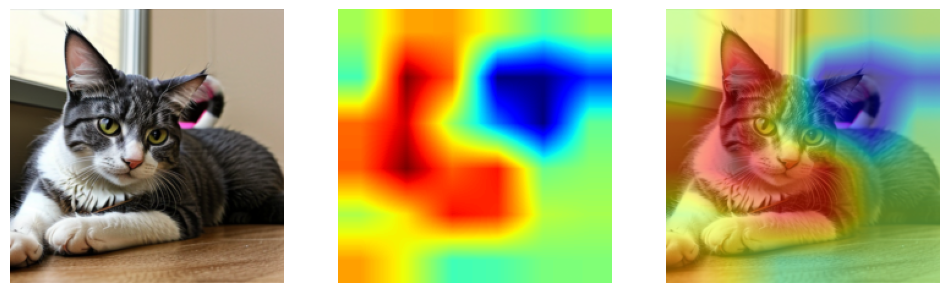

In [ ]:
def grad_cam(model, image):
    grads, acts = [], []

    def fwd(m,i,o): acts.append(o)
    def bwd(m,gi,go): grads.append(go[0])

    layer = model.features[-1]
    h1 = layer.register_forward_hook(fwd)
    h2 = layer.register_backward_hook(bwd)

    out = model(image)
    cls = torch.argmax(out)

    model.zero_grad()
    out[0,cls].backward()

    g = grads[0]
    a = acts[0]

    w = torch.mean(g, dim=(2,3), keepdim=True)
    cam = torch.sum(w*a, dim=1)
    cam = torch.relu(cam).squeeze().detach().cpu().numpy()

    h1.remove(); h2.remove()
    return cam

cam = grad_cam(model, img_for_model)
orig, heat, over = overlay(img_for_model, cam)

plt.figure(figsize=(12,4))
for i,im in enumerate([orig,heat,over]):
    plt.subplot(1,3,i+1)
    plt.imshow(im)
    plt.axis('off')
plt.show()

## Task 3: Grad-CAM++

### Description
Grad-CAM++ improves Grad-CAM by better localization and handling multiple regions.

### Task
- Implement Grad-CAM++  
- Compare with Grad-CAM  

### Expected Output
- Comparison of Grad-CAM vs Grad-CAM++  

WORKING Grad-CAM

In [ ]:
def grad_cam(model, image):
    model.eval()

    image = image.clone().detach().to(DEVICE)
    image.requires_grad = True

    # Forward pass
    features = model.features(image)
    features.retain_grad()

    x = model.avgpool(features)
    x = torch.flatten(x, 1)
    output = model.classifier(x)

    pred_class = output.argmax(dim=1)

    # Backward
    model.zero_grad()
    output[0, pred_class].backward()

    grad = features.grad
    act = features

    weights = torch.mean(grad, dim=(2,3), keepdim=True)

    cam = torch.sum(weights * act, dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    return cam

WORKING Grad-CAM++

In [ ]:
def grad_cam_plus_plus(model, image):
    model.eval()

    image = image.clone().detach().to(DEVICE)
    image.requires_grad = True

    features = model.features(image)
    features.retain_grad()

    x = model.avgpool(features)
    x = torch.flatten(x, 1)
    output = model.classifier(x)

    pred_class = output.argmax(dim=1)

    model.zero_grad()
    output[0, pred_class].backward()

    grad = features.grad
    act = features

    grad_2 = grad ** 2
    grad_3 = grad ** 3

    eps = 1e-8
    sum_act = torch.sum(act, dim=(2,3), keepdim=True)

    alpha = grad_2 / (2 * grad_2 + sum_act * grad_3 + eps)

    weights = torch.sum(alpha * torch.relu(grad), dim=(2,3), keepdim=True)

    cam = torch.sum(weights * act, dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    return cam

In [ ]:
def show_cam(image_tensor, cam, title):
    img = image_tensor.squeeze().cpu().numpy().transpose(1,2,0)

    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    plt.imshow(img)
    plt.imshow(cam, cmap='jet', alpha=0.4)
    plt.title(title)
    plt.axis('off')

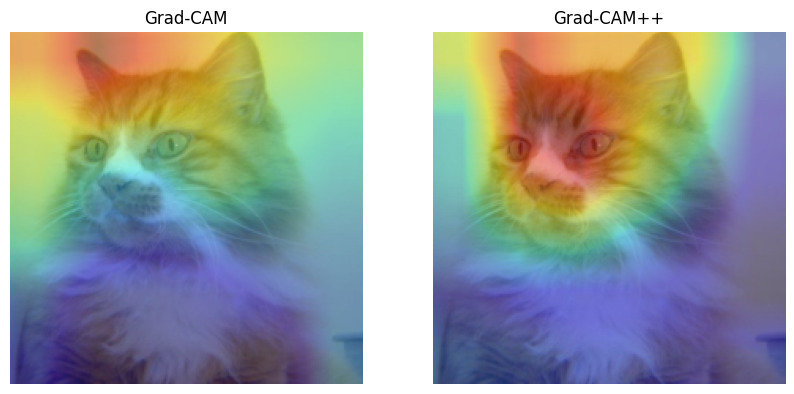

In [ ]:
cam_gc = grad_cam(model, img_for_model)
cam_pp = grad_cam_plus_plus(model, img_for_model)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
show_cam(img_for_model, cam_gc, "Grad-CAM")

plt.subplot(1,2,2)
show_cam(img_for_model, cam_pp, "Grad-CAM++")

plt.show()

**Prediction**


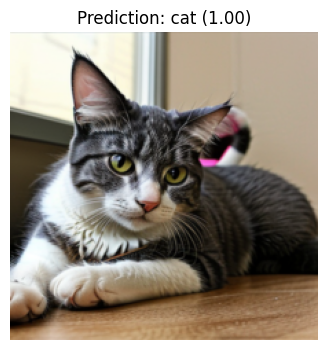

In [ ]:
class_names = val_dataset.classes

model.eval()
with torch.no_grad():
    output = model(img_for_model)
    probs = torch.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

pred_label = class_names[pred_class]
confidence = probs[0, pred_class].item()

# Display result
plt.figure(figsize=(4,4))
orig = img_for_model.squeeze().cpu().detach().numpy().transpose(1,2,0)
orig = (orig - orig.min())/(orig.max()-orig.min())
plt.imshow(orig)
plt.title(f"Prediction: {pred_label} ({confidence:.2f})")
plt.axis('off')
plt.show()